# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import ladder_ddpm, plot_acceptance_over_time, plot_acceptance_over_position

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

Running with 100 steps for [6. 5. 4. 3. 2. 1.]
f avg: -0.0002
f std: 0.0003
Time 87: Swap 5.0 and 4.0 tsr diff 0.00044989585876464844 mean acceptance 1.0
f avg: -0.0007
f std: 0.0011
Time 87: Swap 3.0 and 2.0 tsr diff 0.0014941692352294922 mean acceptance 0.9999990463256836
f avg: -0.0004
f std: 0.0007
Time 81: Swap 6.0 and 5.0 tsr diff 0.000700831413269043 mean acceptance 0.9999998211860657
f avg: -0.0012
f std: 0.0020
Time 81: Swap 4.0 and 3.0 tsr diff 0.0017440319061279297 mean acceptance 0.9999979138374329
f avg: -0.0046
f std: 0.0076
Time 81: Swap 2.0 and 1.0 tsr diff 0.010269999504089355 mean acceptance 0.9999515414237976
f avg: -0.0015
f std: 0.0027
Time 76: Swap 5.0 and 4.0 tsr diff 0.001787424087524414 mean acceptance 0.9999971389770508
f avg: -0.0055
f std: 0.0095
Time 76: Swap 3.0 and 2.0 tsr diff 0.005879878997802734 mean acceptance 0.9999668598175049
  t        :    99  |    98  |    97  |    96  |    95  |    94  |    93  |    92  |    91  |    90  |    89  |    88  |    

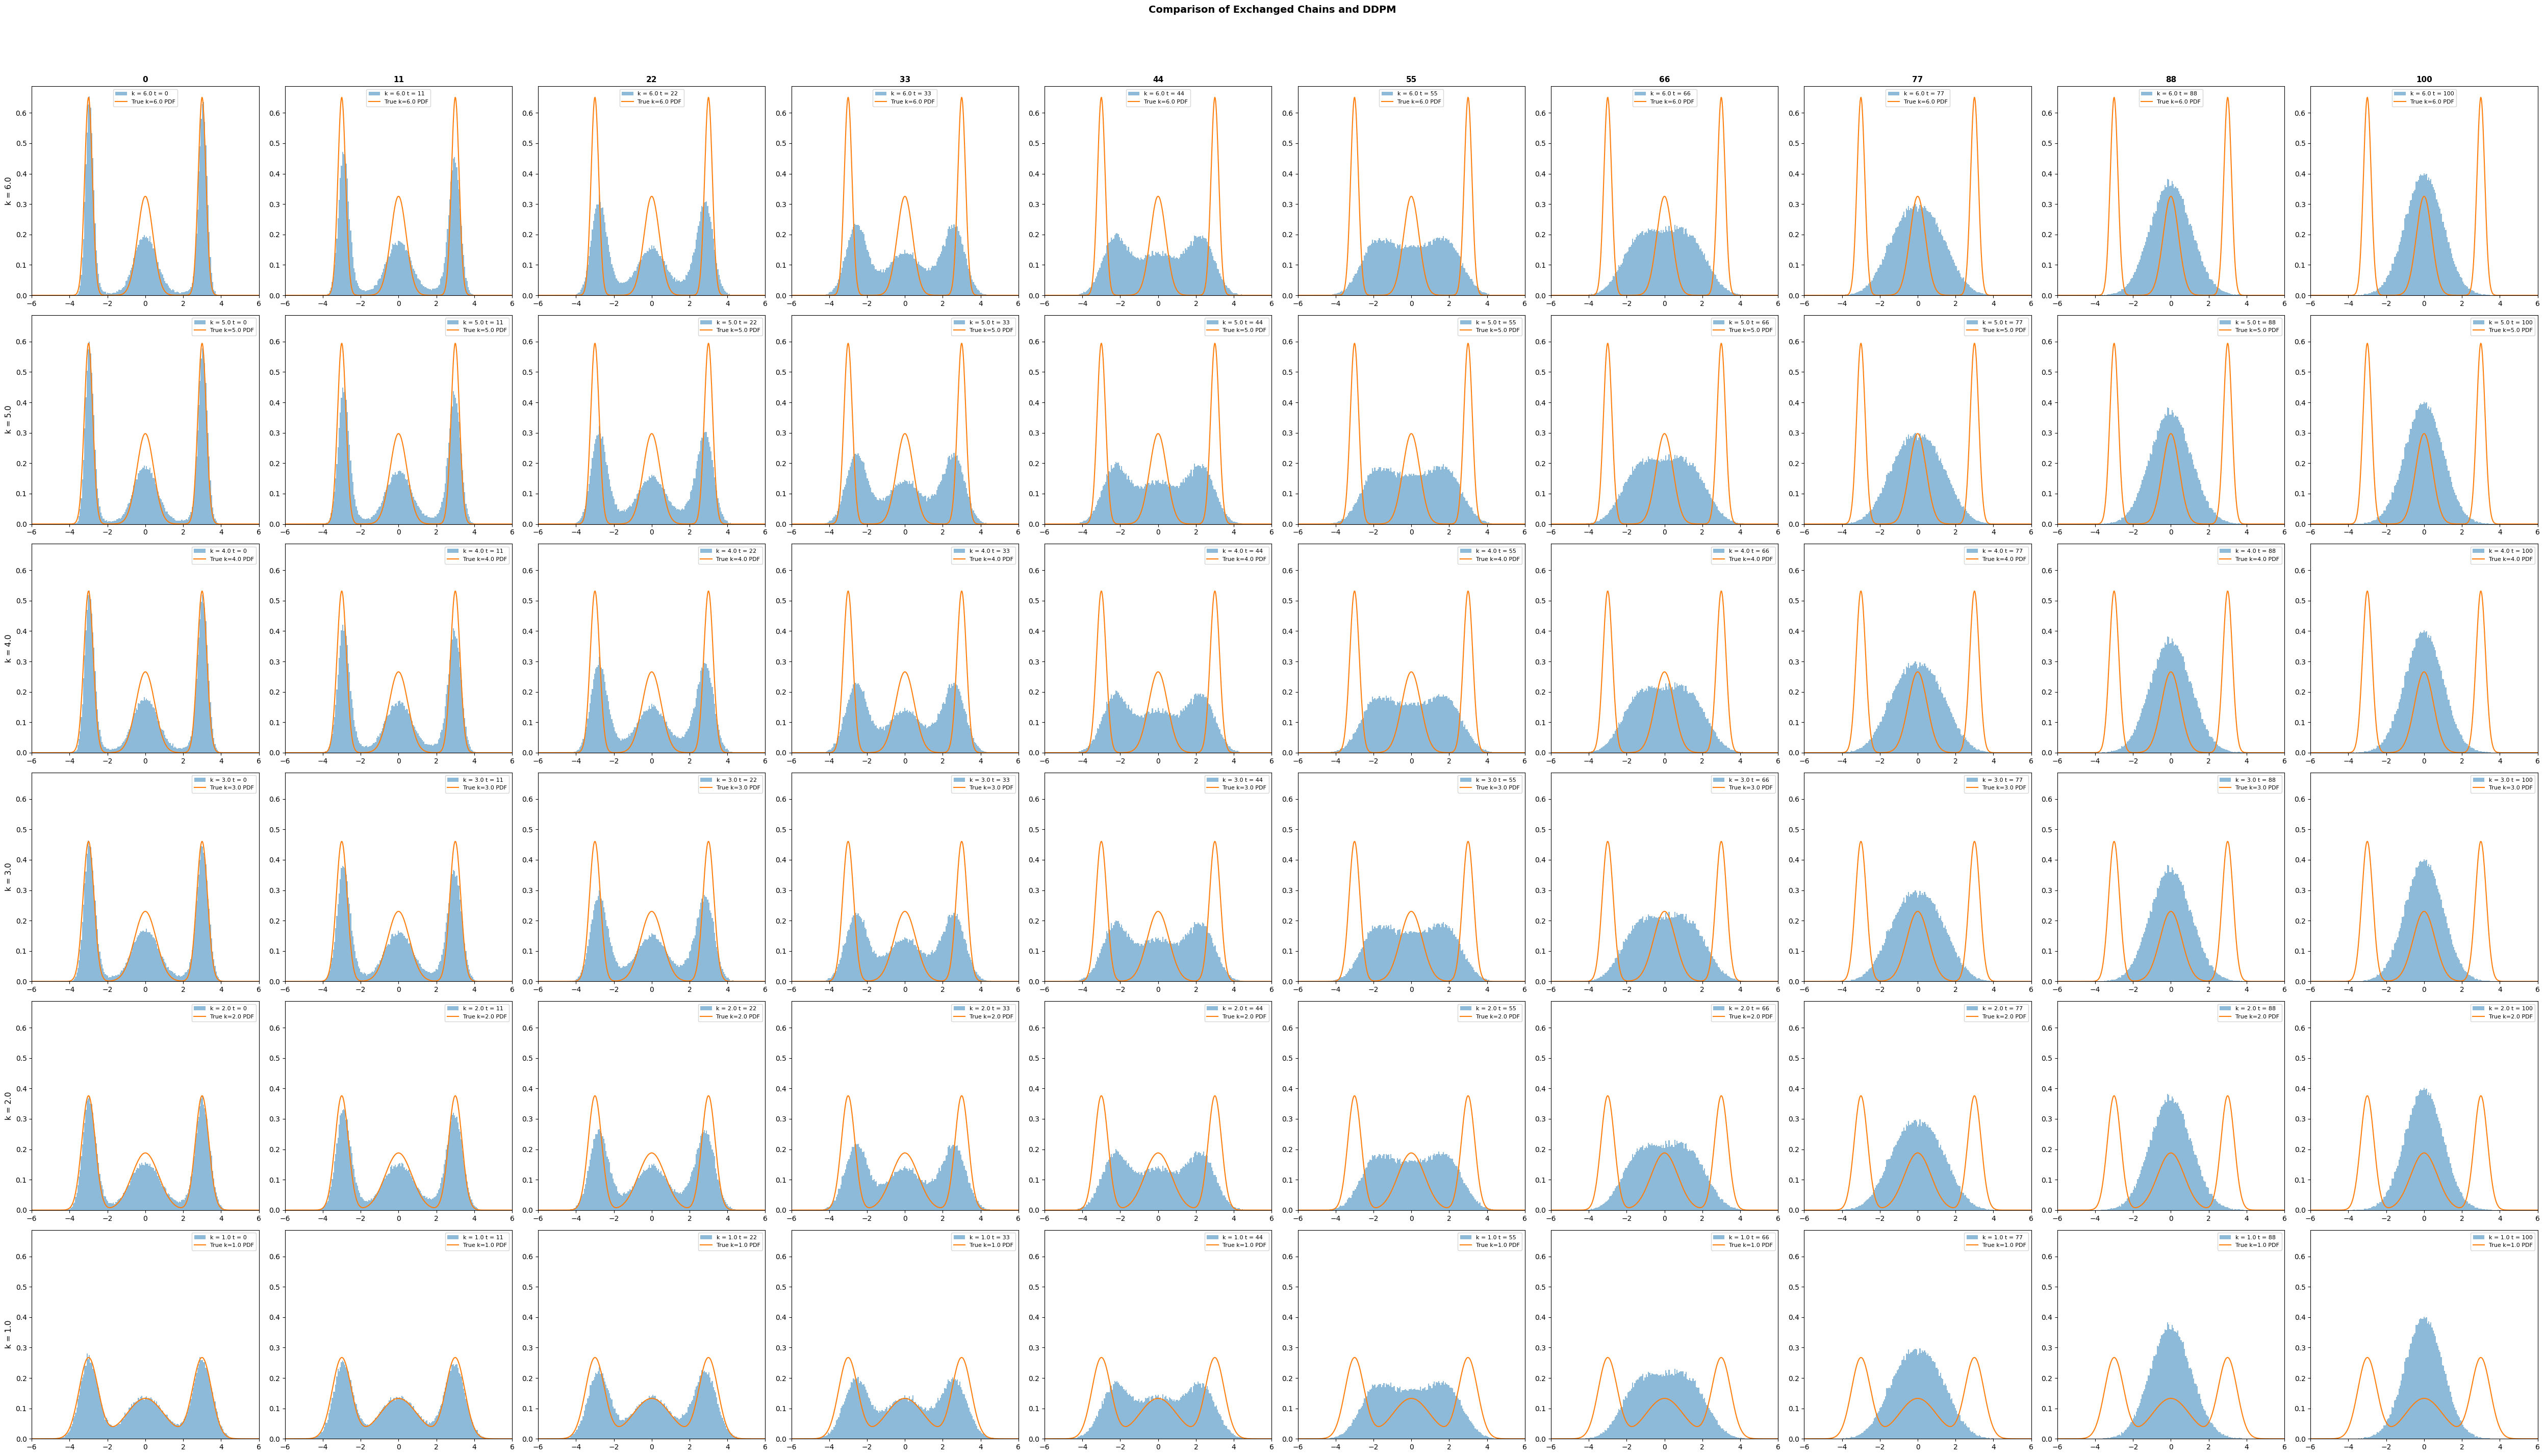

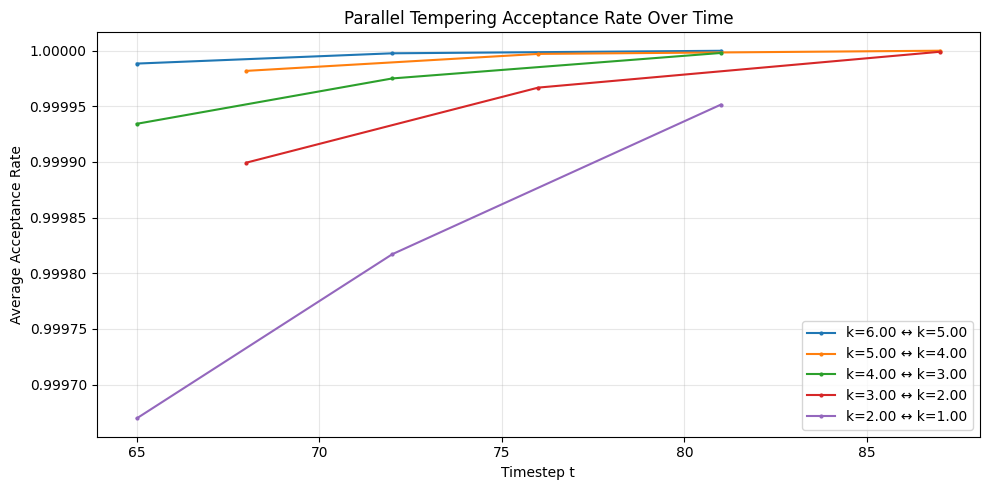

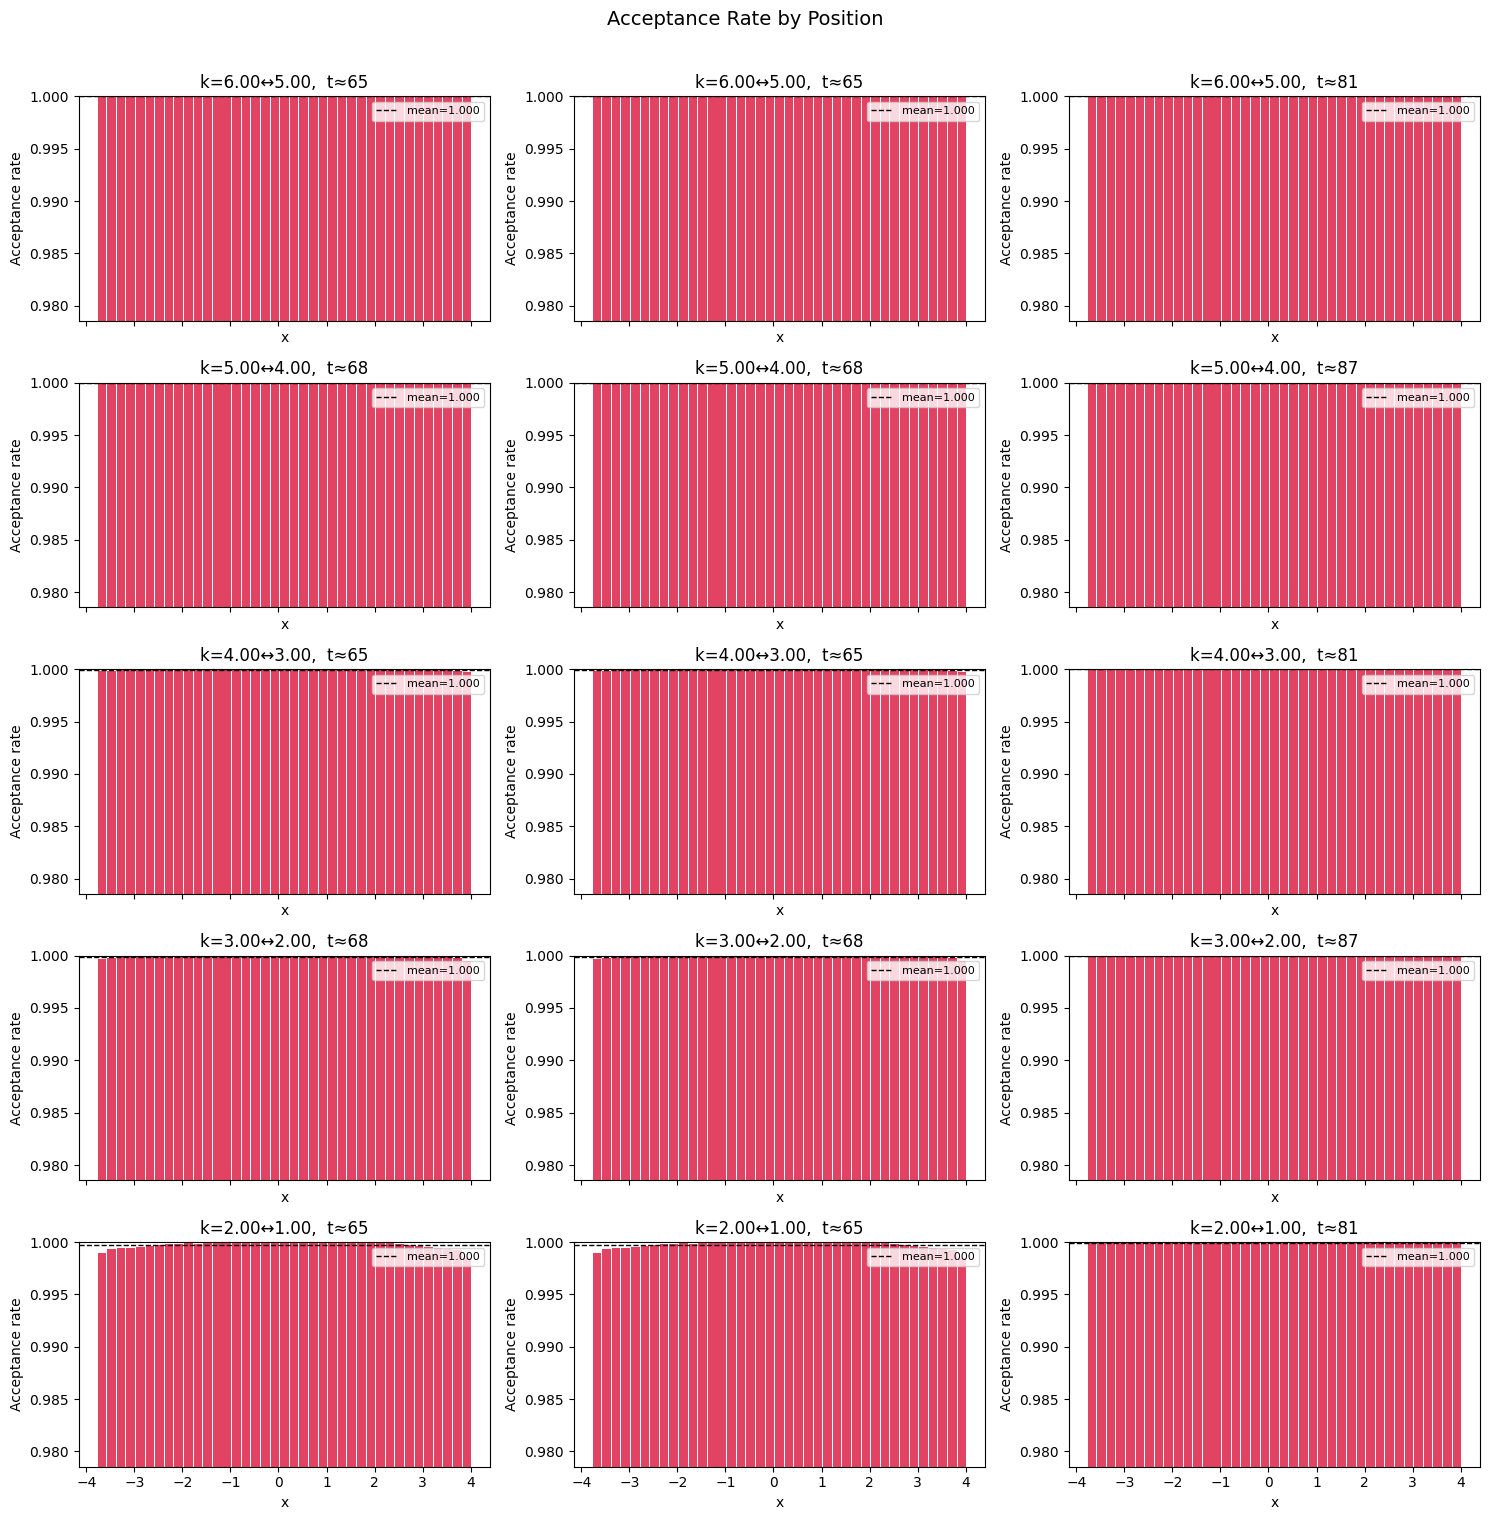

In [2]:
dataset_name = "composed"
k = 6.0
sigma = 0.5
step_scale = 1
n_langevin_steps = 3
n_replicas = 6

x_ladder, a_ladder = ladder_ddpm(dataset_name, k, sigma, step_scale, n_langevin_steps, n_replicas, x_limit=6, save_dir="figures", figsize_per_panel=(5,4), filename=None)
plot_acceptance_over_time(a_ladder)
_ = plot_acceptance_over_position(a_ladder, x_ladder[0][k])

87,
81,
76,
72,
68,
65,


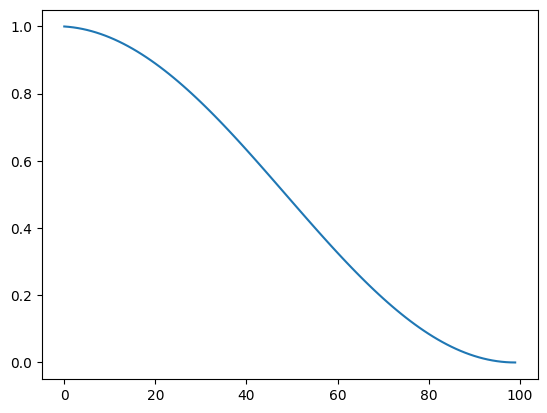

In [3]:
import matplotlib.pyplot as plt
from src.schedule import alpha_bars
import torch

targets = [0.95, 0.9,0.85, 0.8, 0.75, 0.7]
for target in targets:
    idx = (alpha_bars.cpu() - target).abs().argmin().item()
    print(f"{100-idx},")

plt.plot(alpha_bars.cpu().numpy())
plt.show()